# Imports

In [1]:
import torch
from torch import nn
import torchvision
from torchinfo import summary
from torchvision import transforms

from going_modular.going_modular import data_setup, engine, evaluation

import numpy as np
import cv2
import json
import os
import zipfile
from pathlib import Path

from timeit import default_timer as timer
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import seaborn as sns
from thop import profile
import h5py
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedGroupKFold
import shutil
import random

print(torch.__version__) # want 1.12+
print(torchvision.__version__) # want 0.13+

2.7.1+cu128
0.22.1+cu128


In [2]:
# setup device agnostic code 
device = 'cuda' if torch.cuda.is_available() else 'cup'
print(device) 
!nvidia-smi

cuda
Sat May  9 18:50:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5080      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   45C    P5             39W /  360W |    2478MiB /  16303MiB |     19%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+

# Important Functions

In [3]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

In [4]:
def compute_flops(model, input_channels):
    dummy_input = torch.randn(1, input_channels, 224, 224).to(device)
    flops, params = profile(model, inputs=(dummy_input,), verbose=False)
    return flops, params


In [5]:
def plot_results(results):
    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(14,5))

    # ---- LOSS ----
    plt.subplot(1,2,1)
    plt.plot(epochs, results["train_loss"], label="Train Loss")
    plt.plot(epochs, results["test_loss"], label="Test Loss")
    plt.title("Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    # ---- ACCURACY ----
    plt.subplot(1,2,2)
    plt.plot(epochs, results["train_acc"], label="Train Accuracy")
    plt.plot(epochs, results["test_acc"], label="Test Accuracy")
    plt.title("Accuracy Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

In [6]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

# 1.Get Data (DO NOT RUN)
* patient wise mapping

In [10]:
files = [f for f in os.listdir("brainDataset") if f.endswith(".mat")]
print("Total files:", len(files))

Total files: 3064


In [21]:
# before split we need to confirm what key contains patient ID 

file_path = "brainDataset/1.mat"

with h5py.File(file_path, "r") as f:
    cjdata = f["cjdata"]
    
    print("Inside cjdata:")
    for key in cjdata.keys():
        print(key)

Inside cjdata:
PID
image
label
tumorBorder
tumorMask


## 1.1 Start Spliting 
 * Build patient => slices mapping
 * Split patients (Not Slices)
 * Build train/test file lists
 * Extract label
 * check class distribution

In [24]:
# build patient
dataset_path = "brainDataset"

patient_dict = defaultdict(list)

for file in os.listdir(dataset_path):
    if file.endswith(".mat"):
        file_path = os.path.join(dataset_path, file)

        with h5py.File(file_path, "r") as f:
            pid = int(f["cjdata"]["PID"][()][0][0])  # extract patient ID

        patient_dict[pid].append(file_path)

print("Total patients:", len(patient_dict))

Total patients: 5


In [27]:
# split patients 
patient_ids = list(patient_dict.keys())

train_ids, test_ids = train_test_split(
    patient_ids,
    test_size=0.2,
    random_state=42
)

In [28]:
# build train /test file lists
train_files = []
test_files = []

for pid in train_ids:
    train_files.extend(patient_dict[pid])

for pid in test_ids:
    test_files.extend(patient_dict[pid])

print("Train patients:", len(train_ids))
print("Test patients:", len(test_ids))
print("Train samples:", len(train_files))
print("Test samples:", len(test_files))

Train patients: 4
Test patients: 1
Train samples: 2663
Test samples: 401


In [31]:
# make sure no overlap
assert set(train_ids).isdisjoint(set(test_ids))
# Extract label (for late)
def get_label(file_path):
    with h5py.File(file_path, "r") as f:
        label = int(f["cjdata"]["label"][()][0][0])
    return label

In [32]:
# check class distribution
from collections import Counter

train_labels = [get_label(f) for f in train_files]
test_labels = [get_label(f) for f in test_files]

print("Train distribution:", Counter(train_labels))
print("Test distribution:", Counter(test_labels))

Train distribution: Counter({2: 1359, 3: 718, 1: 586})
Test distribution: Counter({3: 212, 1: 122, 2: 67})


In [40]:


# ==============================
# PATHS
# ==============================
dataset_path = "brainDataset"
output_path = "brainDataset_split"

train_path = os.path.join(output_path, "train")
test_path = os.path.join(output_path, "test")

# ==============================
# CREATE FOLDERS
# ==============================
classes = {
    1: "glioma",
    2: "meningioma",
    3: "pituitary"
}

for split in ["train", "test"]:
    for cls in classes.values():
        os.makedirs(os.path.join(output_path, split, cls), exist_ok=True)

# ==============================
# STEP 1: BUILD PATIENT DICTIONARY
# ==============================
patient_dict = defaultdict(list)

for file in os.listdir(dataset_path):
    if file.endswith(".mat"):
        file_path = os.path.join(dataset_path, file)

        with h5py.File(file_path, "r") as f:
            pid = int(f["cjdata"]["PID"][()][0][0])

        patient_dict[pid].append(file_path)

print("Total patients:", len(patient_dict))

# ==============================
# STEP 2: SPLIT PATIENTS
# ==============================
patient_ids = list(patient_dict.keys())

train_ids, test_ids = train_test_split(
    patient_ids,
    test_size=0.2,
    random_state=42
)

# ==============================
# SAVE PATIENT IDS
# ==============================
with open("train_patient_ids.json", "w") as f:
    json.dump(train_ids, f)

with open("test_patient_ids.json", "w") as f:
    json.dump(test_ids, f)

print("Patient IDs saved.")

# ==============================
# HELPER: GET LABEL
# ==============================
def get_label(file_path):
    with h5py.File(file_path, "r") as f:
        label = int(f["cjdata"]["label"][()][0][0])
    return label

# ==============================
# STEP 3: COPY FILES
# ==============================
def copy_files(patient_ids, destination_root):
    for pid in patient_ids:
        for file_path in patient_dict[pid]:
            label = get_label(file_path)
            class_name = classes[label]

            dest_folder = os.path.join(destination_root, class_name)

            shutil.copy(file_path, dest_folder)

# Copy train and test
copy_files(train_ids, train_path)
copy_files(test_ids, test_path)

print("Dataset successfully split and copied.")

Total patients: 5
Patient IDs saved.
Dataset successfully split and copied.


In [43]:
## saves the dataset split (images not mat) to folders 
input_root = "brainDataset_split"
output_root = "brainDataset_images"

for split in ["train", "test"]:
    for cls in ["glioma", "meningioma", "pituitary"]:
        
        input_folder = os.path.join(input_root, split, cls)
        output_folder = os.path.join(output_root, split, cls)
        os.makedirs(output_folder, exist_ok=True)

        for file in os.listdir(input_folder):
            if file.endswith(".mat"):
                file_path = os.path.join(input_folder, file)

                with h5py.File(file_path, "r") as f:
                    image = f["cjdata"]["image"][()]
                
                # Convert to numpy array and normalize
                image = np.array(image)
                image = (image - image.min()) / (image.max() - image.min()) * 255
                image = image.astype(np.uint8)

                # Save as PNG
                save_name = file.replace(".mat", ".png")
                save_path = os.path.join(output_folder, save_name)

                cv2.imwrite(save_path, image)

print("Conversion completed.")

Conversion completed.


In [44]:
print("Train files:", sum(len(files) for _, _, files in os.walk(train_path)))
print("Test files:", sum(len(files) for _, _, files in os.walk(test_path)))

Train files: 2663
Test files: 401


# 1.2 patient-level stratified split (StratifiedGroupKFold)
we want to split : 
* by patient IDs
* while preserving class distribution
That means each patient needs one label. Since a patient may have multiple slices, we will assign each patient:
The majority class among that patient's slices then we stratify on that label

In [49]:

# ==============================
# PATHS
# ==============================
dataset_path = "brainDataset"
output_path = "brainDataset_split_stratified"

train_path = os.path.join(output_path, "train")
test_path = os.path.join(output_path, "test")

classes = {
    1: "glioma",
    2: "meningioma",
    3: "pituitary"
}

# ==============================
# CREATE FOLDERS
# ==============================
for split in ["train", "test"]:
    for cls in classes.values():
        os.makedirs(os.path.join(output_path, split, cls), exist_ok=True)

# ==============================
# STEP 1: BUILD PATIENT -> FILES
# ==============================
patient_dict = defaultdict(list)
patient_labels_dict = defaultdict(list)

for file in os.listdir(dataset_path):
    if file.endswith(".mat"):
        file_path = os.path.join(dataset_path, file)

        with h5py.File(file_path, "r") as f:
            pid = int(f["cjdata"]["PID"][()][0][0])
            label = int(f["cjdata"]["label"][()][0][0])

        patient_dict[pid].append(file_path)
        patient_labels_dict[pid].append(label)

print("Total patients:", len(patient_dict))

# ==============================
# STEP 2: ASSIGN ONE LABEL PER PATIENT
# ==============================
patient_ids = []
patient_majority_labels = []

for pid, labels in patient_labels_dict.items():
    majority_label = Counter(labels).most_common(1)[0][0]
    patient_ids.append(pid)
    patient_majority_labels.append(majority_label)

print("Original distribution:")
print(Counter(patient_majority_labels))

# ==============================
# STEP 3: REMOVE RARE CLASSES (<2 patients)
# ==============================
label_counts = Counter(patient_majority_labels)

filtered_patient_ids = []
filtered_labels = []

for pid, label in zip(patient_ids, patient_majority_labels):
    if label_counts[label] >= 2:
        filtered_patient_ids.append(pid)
        filtered_labels.append(label)

print("Filtered distribution:")
print(Counter(filtered_labels))

# ==============================
# STEP 4: STRATIFIED GROUP SPLIT
# ==============================
X_dummy = np.zeros(len(filtered_patient_ids))
y = np.array(filtered_labels)
groups = np.array(filtered_patient_ids)

n_splits = min(2, len(filtered_patient_ids)) 

sgkf = StratifiedGroupKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

for train_idx, test_idx in sgkf.split(X_dummy, y, groups):
    train_ids = groups[train_idx]
    test_ids = groups[test_idx]
    break  # نأخذ أول fold فقط

# ==============================
# SAVE PATIENT IDS
# ==============================
with open("train_patient_ids.json", "w") as f:
    json.dump(train_ids.tolist(), f)

with open("test_patient_ids.json", "w") as f:
    json.dump(test_ids.tolist(), f)

print("Patient IDs saved.")

# ==============================
# HELPER: GET LABEL
# ==============================
def get_label(file_path):
    with h5py.File(file_path, "r") as f:
        label = int(f["cjdata"]["label"][()][0][0])
    return label

# ==============================
# STEP 5: COPY FILES
# ==============================
def copy_files(patient_ids, destination_root):
    for pid in patient_ids:
        for file_path in patient_dict[pid]:
            label = get_label(file_path)
            class_name = classes[label]
            dest_folder = os.path.join(destination_root, class_name)
            shutil.copy(file_path, dest_folder)

copy_files(train_ids, train_path)
copy_files(test_ids, test_path)

print("✅ Dataset successfully split using Stratified Group Split.")

Total patients: 5
Original distribution:
Counter({3: 2, 2: 2, 1: 1})
Filtered distribution:
Counter({3: 2, 2: 2})
Patient IDs saved.
✅ Dataset successfully split using Stratified Group Split.


# 2 DataSet (Cropping, Resize, Augmentation)
## 2.1 Data Cropping And Noise Removel

In [6]:

# ==============================
# PATHS
# ==============================
input_root = "brainDataset_images"      # change if your current image dataset folder has another name
output_root = "cropped_data_set"

# ==============================
# CREATE OUTPUT FOLDERS
# ==============================
for split in ["train", "test"]:
    for cls in ["glioma", "meningioma", "pituitary"]:
        os.makedirs(os.path.join(output_root, split, cls), exist_ok=True)

# ==============================
# CROP FUNCTION
# ==============================
def crop_brain_contour(image, add_pixels=0):
    """
    Crops the brain region based on the largest contour.
    Returns cropped image.
    If no contour is found, returns original image.
    """

    # If image is RGB/BGR convert to grayscale
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()

    # Gaussian blur
    gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Threshold
    _, thresh = cv2.threshold(gray_blur, 45, 255, cv2.THRESH_BINARY)

    # Morphological operations: erosion then dilation
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    # Find contours
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # If no contours found, return original image
    if len(contours) == 0:
        return image

    # Largest contour
    c = max(contours, key=cv2.contourArea)

    # Extreme points
    ext_left = tuple(c[c[:, :, 0].argmin()][0])
    ext_right = tuple(c[c[:, :, 0].argmax()][0])
    ext_top = tuple(c[c[:, :, 1].argmin()][0])
    ext_bottom = tuple(c[c[:, :, 1].argmax()][0])

    # Coordinates with optional padding
    x1 = max(ext_left[0] - add_pixels, 0)
    x2 = min(ext_right[0] + add_pixels, image.shape[1])
    y1 = max(ext_top[1] - add_pixels, 0)
    y2 = min(ext_bottom[1] + add_pixels, image.shape[0])

    cropped = image[y1:y2, x1:x2]

    # Safety check
    if cropped.size == 0:
        return image

    return cropped

# ==============================
# PROCESS ALL IMAGES
# ==============================
valid_exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

for split in ["train", "test"]:
    for cls in ["glioma", "meningioma", "pituitary"]:
        input_dir = os.path.join(input_root, split, cls)
        output_dir = os.path.join(output_root, split, cls)

        files = [f for f in os.listdir(input_dir) if f.lower().endswith(valid_exts)]

        print(f"Processing {split}/{cls} ... {len(files)} images")

        for file_name in files:
            img_path = os.path.join(input_dir, file_name)

            # Read image
            img = cv2.imread(img_path)
            if img is None:
                print(f"Could not read: {img_path}")
                continue

            # Crop
            cropped_img = crop_brain_contour(img, add_pixels=0)

            # Save
            save_path = os.path.join(output_dir, file_name)
            cv2.imwrite(save_path, cropped_img)

print("Done. Cropped dataset saved in:", output_root)

Processing train/glioma ... 586 images
Processing train/meningioma ... 1359 images
Processing train/pituitary ... 718 images
Processing test/glioma ... 122 images
Processing test/meningioma ... 67 images
Processing test/pituitary ... 212 images
Done. Cropped dataset saved in: cropped_data_set


## 2.2 Augmentation and Resizing

* read from your cropped dataset folder
* resize all images to 224×224×3
* apply augmentation only to the training set
* keep the test set resized only, with no augmentation
* save everything into a new directory named dataset_for_training
* preserve the class-folder structure

In [7]:
# =====================================
# PATHS
# =====================================
input_root = "cropped_data_set"
output_root = "dataset_for_training"

classes = ["glioma", "meningioma", "pituitary"]
splits = ["train", "test"]

# =====================================
# SETTINGS
# =====================================
target_size = (224, 224)   # width, height
valid_exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

# Number of extra augmented samples to create per training image
# Example:
# 0 -> save only original resized image
# 1 -> original + 1 augmented copy
# 2 -> original + 2 augmented copies
num_aug_per_image = 4

random.seed(42)
np.random.seed(42)

# =====================================
# CREATE OUTPUT FOLDERS
# =====================================
for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(output_root, split, cls), exist_ok=True)

# =====================================
# AUGMENTATION FUNCTIONS
# =====================================
def resize_to_rgb(image, size=(224, 224)):
    """
    Resize image and ensure it is 3-channel RGB-like (saved as standard 3-channel image).
    OpenCV uses BGR internally, which is fine for saving.
    """
    # If grayscale -> convert to 3 channels
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    elif image.shape[2] == 1:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    image = cv2.resize(image, size, interpolation=cv2.INTER_AREA)
    return image

def rotate_image(image, angle):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    # Keep black border after rotation
    rotated = cv2.warpAffine(
        image,
        M,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )
    return rotated

def random_augmentation(image):
    """
    Applies random rotation + optional horizontal/vertical flips.
    """
    aug = image.copy()

    # Random rotation between -20 and +20 degrees
    angle = random.uniform(-20, 20)
    aug = rotate_image(aug, angle)

    # Random horizontal flip
    if random.random() < 0.5:
        aug = cv2.flip(aug, 1)

    # Random vertical flip
    if random.random() < 0.5:
        aug = cv2.flip(aug, 0)

    return aug

# =====================================
# PROCESS DATASET
# =====================================
for split in splits:
    for cls in classes:
        input_dir = os.path.join(input_root, split, cls)
        output_dir = os.path.join(output_root, split, cls)

        files = [f for f in os.listdir(input_dir) if f.lower().endswith(valid_exts)]
        print(f"Processing {split}/{cls} -> {len(files)} images")

        for file_name in files:
            input_path = os.path.join(input_dir, file_name)

            img = cv2.imread(input_path, cv2.IMREAD_UNCHANGED)
            if img is None:
                print(f"Skipping unreadable file: {input_path}")
                continue

            # Resize original image to 224x224x3
            img_resized = resize_to_rgb(img, target_size)

            base_name = os.path.splitext(file_name)[0]

            # Save original resized image
            save_original_path = os.path.join(output_dir, f"{base_name}.png")
            cv2.imwrite(save_original_path, img_resized)

            # Apply augmentation ONLY on training set
            if split == "train":
                for i in range(num_aug_per_image):
                    aug_img = random_augmentation(img_resized)
                    save_aug_path = os.path.join(output_dir, f"{base_name}_aug_{i+1}.png")
                    cv2.imwrite(save_aug_path, aug_img)

print(f"\nDone. Final dataset saved in: {output_root}")

Processing train/glioma -> 586 images
Processing train/meningioma -> 1243 images
Processing train/pituitary -> 718 images
Processing test/glioma -> 122 images
Processing test/meningioma -> 63 images
Processing test/pituitary -> 212 images

Done. Final dataset saved in: dataset_for_training


## 2.3 prepare dataloaders for training 

In [7]:
from torchvision import transforms

# ==============================
# PATHS
# ==============================
train_dir = "dataset_for_training/train"
test_dir = "dataset_for_training/test"

# ==============================
# TRANSFORMS
# ==============================
manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# ==============================
# DATALOADERS
# ==============================
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms,
    batch_size=32
)

train_dataloader, test_dataloader, class_names

length of train_data 12735 length of test_data 397 class names ['glioma', 'meningioma', 'pituitary']


(<torch.utils.data.dataloader.DataLoader at 0x1c9626e3d90>,
 ['glioma', 'meningioma', 'pituitary'])

# 3- ZubNet-A Model Blocks

In [11]:
#Input (1x224x224 or 3x224x224)
#      ↓
#Stem (Conv → BN → ReLU → Downsample)
#      ↓
#Stage 1: 2 × ZubBlock
#      ↓
#Downsample
#      ↓
#Stage 2: 3 × ZubBlock
#      ↓
#Downsample
#      ↓
#Stage 3: 4 × ZubBlock
#      ↓
#Global Average Pooling
#     ↓
#Classifier Head (Linear → BN → ReLU → Dropout → Linear)
#      ↓
#Softmax (3 classes)


In [9]:
# first block 
# Squeeze-and-Excitation block
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w

In [10]:
class ZubBlockA_v2(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ZubBlockA_v2, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

        self.dwconv = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride,
                      padding=1, groups=out_channels, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

        self.se = SEBlock(out_channels)

        self.dropout = nn.Dropout2d(0.1)  # NEW REGULARIZATION

        # Shortcut
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        self.relu = nn.ReLU()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.dwconv(out)
        out = self.se(out)
        out = self.dropout(out)   # NEW
        out = out + identity
        return self.relu(out)


In [11]:
# model A 
class ZubNetA(nn.Module):
    def __init__(self, num_classes=3):
        super(ZubNetA, self).__init__()

        # 1-channel MRI input
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        # Stage 1 (2 blocks, 32 channels)
        self.stage1 = nn.Sequential(
            ZubBlockA_v2(32, 32, stride=1),
            ZubBlockA_v2(32, 32, stride=1)
        )

        # Downsample → Stage 2 (3 blocks, 96 channels)
        self.down1 = nn.Conv2d(32, 96, kernel_size=1, stride=2)
        self.stage2 = nn.Sequential(
            ZubBlockA_v2(96, 96, stride=1),
            ZubBlockA_v2(96, 96, stride=1),
            ZubBlockA_v2(96, 96, stride=1)
        )

        # Downsample → Stage 3 (4 blocks, 192 channels)
        self.down2 = nn.Conv2d(96, 192, kernel_size=1, stride=2)
        self.stage3 = nn.Sequential(
            ZubBlockA_v2(192, 192, stride=1),
            ZubBlockA_v2(192, 192, stride=1),
            ZubBlockA_v2(192, 192, stride=1),
            ZubBlockA_v2(192, 192, stride=1)
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(192, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)

        x = self.stage1(x)
        x = self.down1(x)

        x = self.stage2(x)
        x = self.down2(x)

        x = self.stage3(x)

        x = self.classifier(x)
        return x

In [12]:
model = ZubNetA(num_classes=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

### Train the model (plot everything)

###  Save and evaluate the model 

In [13]:
# Train the model on new data better data (remove the bad images) 
### train our mmodel 
results_zubA = engine.train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=nn.CrossEntropyLoss(),
    epochs=50,
    device=device
)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.5822 | train_acc: 0.7644 | test_loss: 0.5970 | test_acc: 0.7502
Epoch: 2 | train_loss: 0.3720 | train_acc: 0.8519 | test_loss: 0.2937 | test_acc: 0.8848
Epoch: 3 | train_loss: 0.2728 | train_acc: 0.8959 | test_loss: 0.3541 | test_acc: 0.8534
Epoch: 4 | train_loss: 0.2071 | train_acc: 0.9232 | test_loss: 0.2915 | test_acc: 0.8966
Epoch: 5 | train_loss: 0.1841 | train_acc: 0.9321 | test_loss: 0.1964 | test_acc: 0.9327
Epoch: 6 | train_loss: 0.1567 | train_acc: 0.9428 | test_loss: 0.1914 | test_acc: 0.9471
Epoch: 7 | train_loss: 0.1356 | train_acc: 0.9508 | test_loss: 0.1273 | test_acc: 0.9615
Epoch: 8 | train_loss: 0.1207 | train_acc: 0.9556 | test_loss: 0.1838 | test_acc: 0.9159
Epoch: 9 | train_loss: 0.1069 | train_acc: 0.9603 | test_loss: 0.2199 | test_acc: 0.9447
Epoch: 10 | train_loss: 0.0988 | train_acc: 0.9640 | test_loss: 0.1071 | test_acc: 0.9615
Epoch: 11 | train_loss: 0.0909 | train_acc: 0.9666 | test_loss: 0.2242 | test_acc: 0.9149
Epoch: 12 | train_l

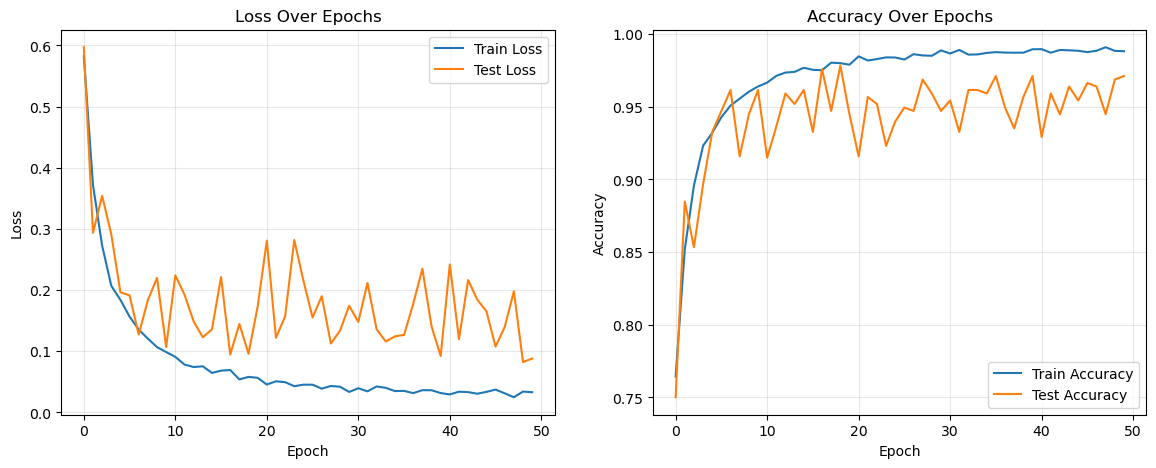

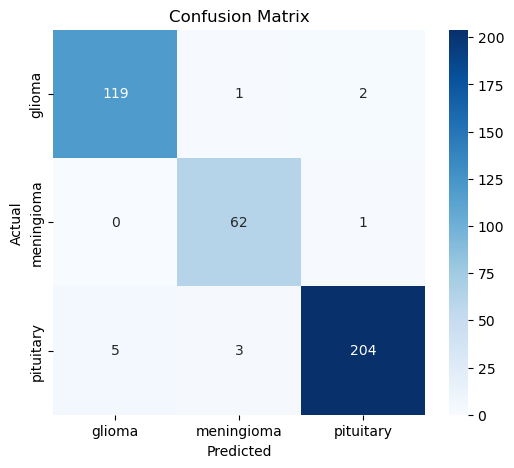

In [14]:
plot_results(results_zubA)
plot_confusion_matrix(results_zubA["labels"][-1], results_zubA["preds"][-1], class_names)

In [15]:
# use evaluate_model function in the evaluation model to check all the matrices
results_eval = evaluation.evaluate_model(
    model=model, 
    dataloader=test_dataloader,
    class_names=class_names,
    device=device
)

print("Accuracy:", results_eval["accuracy"])
print("\nClassification Report:\n", results_eval["classification_report"])
print("\nSpecificity:", results_eval["specificity"])
print("\nConfusion Matrix:\n", results_eval["confusion_matrix"])


Accuracy: 0.9697732997481109

Classification Report:
               precision    recall  f1-score   support

      glioma       0.96      0.98      0.97       122
  meningioma       0.94      0.98      0.96        63
   pituitary       0.99      0.96      0.97       212

    accuracy                           0.97       397
   macro avg       0.96      0.97      0.97       397
weighted avg       0.97      0.97      0.97       397


Specificity: {'glioma': 0.9818181818181818, 'meningioma': 0.9880239520958084, 'pituitary': 0.9837837837837838}

Confusion Matrix:
 [[119   1   2]
 [  0  62   1]
 [  5   3 204]]


In [16]:
# save the model 
torch.save(model.state_dict(), "MyOwnModels/ZubNet_A.pth")
torch.save(model, "MyOwnModels/ZubNet_A_full.pth")

In [17]:
def convert_to_serializable(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


with open("MyOwnModels/zubAresults.json", "w") as f:
    json.dump(results_zubA, f, indent=4, default=convert_to_serializable)

In [18]:
import pickle

with open("MyOwnModels/zubA1results.pkl", "wb") as f:
    pickle.dump(results_zubA, f)

# Train pre-Trained models 

## ResNet-50

In [10]:
import torchvision.models as models


device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- TRANSFORMS (Grayscale → 3-channel) ----
baseline_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
        train_dir=train_dir,
        test_dir=test_dir,
        transform=baseline_transforms,
        batch_size=32
    )

# ---- BASELINE MODEL SELECTION ----
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# REPLACE CLASSIFIER
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))

# ---- LOSS & OPTIMIZER ----
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ---- SCHEDULER (same as ZubNet) ----
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=5,
    factor=0.5,
    min_lr=1e-6
)
# # ---- TRAIN ----
results_resnet50 = engine.train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=50,
    device=device,
    
)



length of train_data 12735 length of test_data 397 class names ['glioma', 'meningioma', 'pituitary']


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.1869 | train_acc: 0.9340 | test_loss: 0.3964 | test_acc: 0.9303
Epoch: 2 | train_loss: 0.0860 | train_acc: 0.9685 | test_loss: 0.0997 | test_acc: 0.9663
Epoch: 3 | train_loss: 0.0551 | train_acc: 0.9816 | test_loss: 0.3481 | test_acc: 0.9099
Epoch: 4 | train_loss: 0.0506 | train_acc: 0.9827 | test_loss: 0.1649 | test_acc: 0.9495
Epoch: 5 | train_loss: 0.0425 | train_acc: 0.9864 | test_loss: 0.9146 | test_acc: 0.7885
Epoch: 6 | train_loss: 0.0349 | train_acc: 0.9881 | test_loss: 0.0641 | test_acc: 0.9832
Epoch: 7 | train_loss: 0.0299 | train_acc: 0.9897 | test_loss: 0.4449 | test_acc: 0.8774
Epoch: 8 | train_loss: 0.0275 | train_acc: 0.9902 | test_loss: 0.1085 | test_acc: 0.9615
Epoch: 9 | train_loss: 0.0207 | train_acc: 0.9932 | test_loss: 0.1187 | test_acc: 0.9567
Epoch: 10 | train_loss: 0.0294 | train_acc: 0.9903 | test_loss: 0.0745 | test_acc: 0.9760
Epoch: 11 | train_loss: 0.0257 | train_acc: 0.9916 | test_loss: 0.1342 | test_acc: 0.9663
Epoch: 12 | train_l

In [11]:
# evaluation
# use evaluate_model function in the evaluation model to check all the matrices
results_eval = evaluation.evaluate_model(
    model=model, 
    dataloader=test_dataloader,
    class_names=class_names,
    device=device
)

print("Accuracy:", results_eval["accuracy"])
print("\nClassification Report:\n", results_eval["classification_report"])
print("\nSpecificity:", results_eval["specificity"])
print("\nConfusion Matrix:\n", results_eval["confusion_matrix"])


Accuracy: 0.9848866498740554

Classification Report:
               precision    recall  f1-score   support

      glioma       0.98      1.00      0.99       122
  meningioma       0.95      0.98      0.97        63
   pituitary       1.00      0.98      0.99       212

    accuracy                           0.98       397
   macro avg       0.98      0.99      0.98       397
weighted avg       0.99      0.98      0.98       397


Specificity: {'glioma': 0.9890909090909091, 'meningioma': 0.9910179640718563, 'pituitary': 1.0}

Confusion Matrix:
 [[122   0   0]
 [  1  62   0]
 [  2   3 207]]


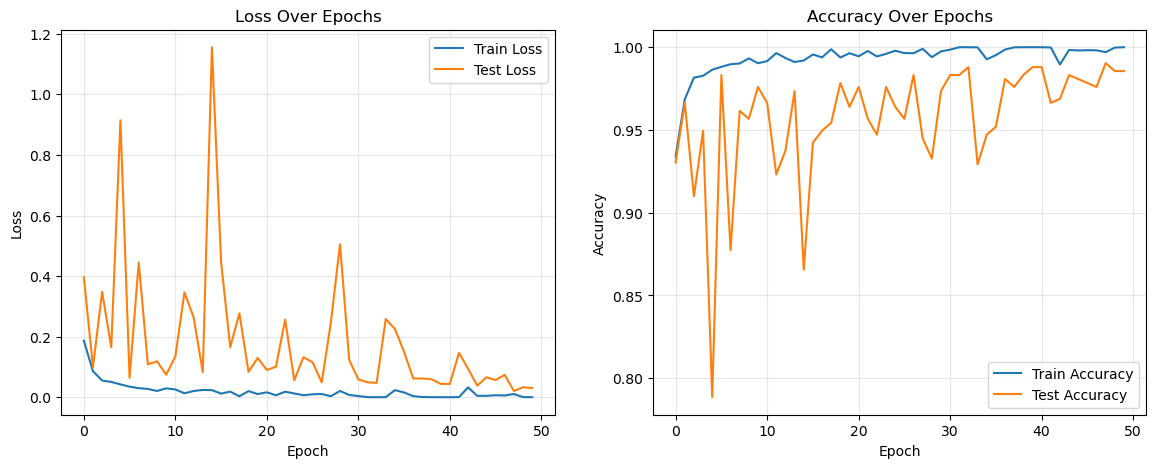

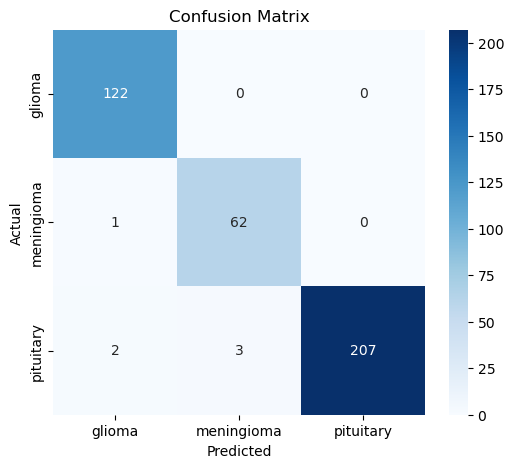

In [12]:
plot_results(results_resnet50)
plot_confusion_matrix(results_resnet50["labels"][-1], results_resnet50["preds"][-1], class_names)

In [13]:
# save the model 
torch.save(model.state_dict(), "theBaseLineModels/ResNet50.pth")
torch.save(model, "theBaseLineModels/ResNet50_full.pth")

def convert_to_serializable(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


with open("theBaseLineModels/ResNet50.json", "w") as f:
    json.dump(results_resnet50, f, indent=4, default=convert_to_serializable)


import pickle

with open("theBaseLineModels/ResNet50.pkl", "wb") as f:
    pickle.dump(results_resnet50, f)

### Dense Net

In [15]:
## DenseNet121 BASELINE MODEL

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- TRANSFORMS (convert MRI 1-channel → 3-channel) ----
baseline_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ---- DATA LOADERS ----
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=baseline_transforms,
    batch_size=32
)

# ---- LOAD DenseNet121 ----
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# ---- REPLACE FINAL CLASSIFIER ----
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 3)

model = model.to(device)

# ---- LOSS & OPTIMIZER ----
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ---- SCHEDULER ----
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=5,
    factor=0.5,
    min_lr=1e-6
)

# ---- TRAIN ----
results_Dense121 = engine.train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=50,
    device=device
)

length of train_data 12735 length of test_data 397 class names ['glioma', 'meningioma', 'pituitary']


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.1797 | train_acc: 0.9341 | test_loss: 0.1236 | test_acc: 0.9615
Epoch: 2 | train_loss: 0.1006 | train_acc: 0.9629 | test_loss: 0.7415 | test_acc: 0.7816
Epoch: 3 | train_loss: 0.0668 | train_acc: 0.9772 | test_loss: 0.6034 | test_acc: 0.8413
Epoch: 4 | train_loss: 0.0537 | train_acc: 0.9811 | test_loss: 0.2661 | test_acc: 0.9255
Epoch: 5 | train_loss: 0.0370 | train_acc: 0.9860 | test_loss: 0.4277 | test_acc: 0.8852
Epoch: 6 | train_loss: 0.0462 | train_acc: 0.9845 | test_loss: 0.1684 | test_acc: 0.9543
Epoch: 7 | train_loss: 0.0408 | train_acc: 0.9856 | test_loss: 0.6473 | test_acc: 0.8077
Epoch: 8 | train_loss: 0.0271 | train_acc: 0.9918 | test_loss: 1.1872 | test_acc: 0.7803
Epoch: 9 | train_loss: 0.0282 | train_acc: 0.9907 | test_loss: 0.0925 | test_acc: 0.9736
Epoch: 10 | train_loss: 0.0232 | train_acc: 0.9918 | test_loss: 0.3423 | test_acc: 0.9159
Epoch: 11 | train_loss: 0.0350 | train_acc: 0.9891 | test_loss: 0.0971 | test_acc: 0.9663
Epoch: 12 | train_l

In [16]:
# evaluation
# use evaluate_model function in the evaluation model to check all the matrices
results_eval = evaluation.evaluate_model(
    model=model, 
    dataloader=test_dataloader,
    class_names=class_names,
    device=device
)

print("Accuracy:", results_eval["accuracy"])
print("\nClassification Report:\n", results_eval["classification_report"])
print("\nSpecificity:", results_eval["specificity"])
print("\nConfusion Matrix:\n", results_eval["confusion_matrix"])


Accuracy: 0.9798488664987406

Classification Report:
               precision    recall  f1-score   support

      glioma       0.98      0.97      0.97       122
  meningioma       0.97      0.98      0.98        63
   pituitary       0.99      0.99      0.99       212

    accuracy                           0.98       397
   macro avg       0.98      0.98      0.98       397
weighted avg       0.98      0.98      0.98       397


Specificity: {'glioma': 0.9890909090909091, 'meningioma': 0.9940119760479041, 'pituitary': 0.9837837837837838}

Confusion Matrix:
 [[118   1   3]
 [  1  62   0]
 [  2   1 209]]


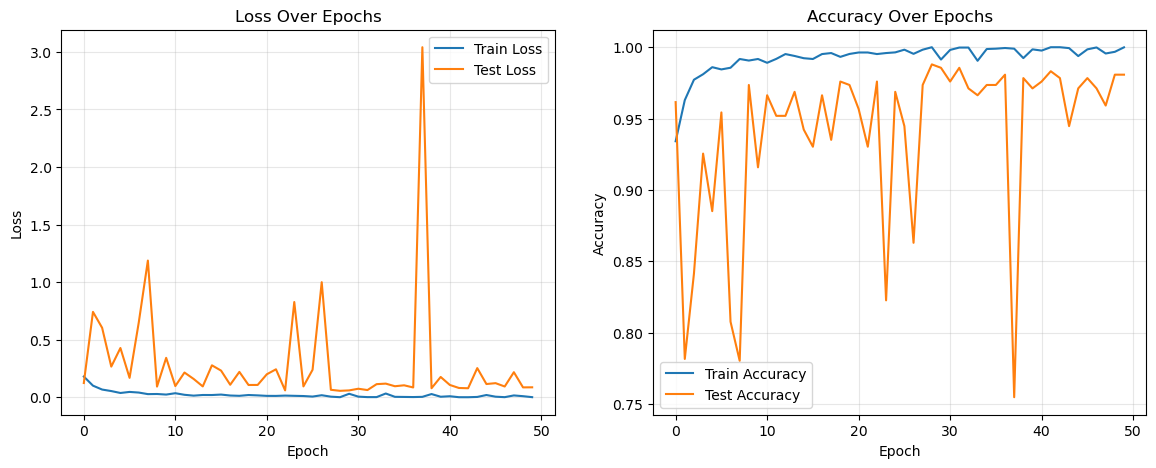

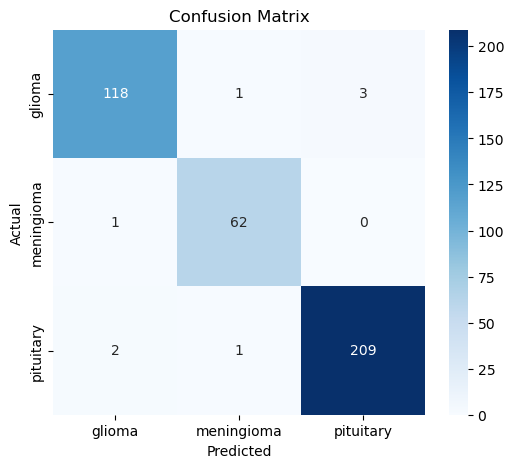

In [17]:
plot_results(results_Dense121)
plot_confusion_matrix(results_Dense121["labels"][-1], results_Dense121["preds"][-1], class_names)

In [18]:
# save the model 
torch.save(model.state_dict(), "theBaseLineModels/Dense121.pth")
torch.save(model, "theBaseLineModels/Dense121_full.pth")

def convert_to_serializable(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


with open("theBaseLineModels/Dense121.json", "w") as f:
    json.dump(results_Dense121, f, indent=4, default=convert_to_serializable)


import pickle

with open("theBaseLineModels/Dense121.pkl", "wb") as f:
    pickle.dump(results_Dense121, f)

### MobileNet

In [19]:
## MobileNetV3 
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- TRANSFORMS (convert MRI 1-channel → 3-channel) ----
baseline_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # MobileNet expects 3-channel
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ---- DATA LOADERS ----
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=baseline_transforms,
    batch_size=32
)

# ---- LOAD MobileNetV3-Large ----
model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)

# ---- REPLACE CLASSIFIER ----
in_features = model.classifier[3].in_features   # last FC layer
model.classifier[3] = nn.Linear(in_features, 3)

model = model.to(device)

# ---- LOSS & OPTIMIZER ----
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ---- SCHEDULER ----
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=5,
    factor=0.5,
    min_lr=1e-6
)

# ---- TRAIN ----
results_MobileNetV3 = engine.train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=50,
    device=device
)


length of train_data 12735 length of test_data 397 class names ['glioma', 'meningioma', 'pituitary']


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.1205 | train_acc: 0.9576 | test_loss: 1.0692 | test_acc: 0.6810
Epoch: 2 | train_loss: 0.0485 | train_acc: 0.9836 | test_loss: 0.1138 | test_acc: 0.9712
Epoch: 3 | train_loss: 0.0355 | train_acc: 0.9892 | test_loss: 0.2258 | test_acc: 0.8983
Epoch: 4 | train_loss: 0.0275 | train_acc: 0.9915 | test_loss: 0.4141 | test_acc: 0.8406
Epoch: 5 | train_loss: 0.0283 | train_acc: 0.9906 | test_loss: 0.0257 | test_acc: 0.9928
Epoch: 6 | train_loss: 0.0271 | train_acc: 0.9921 | test_loss: 0.0645 | test_acc: 0.9856
Epoch: 7 | train_loss: 0.0125 | train_acc: 0.9965 | test_loss: 0.1029 | test_acc: 0.9736
Epoch: 8 | train_loss: 0.0211 | train_acc: 0.9943 | test_loss: 1.3467 | test_acc: 0.8007
Epoch: 9 | train_loss: 0.0164 | train_acc: 0.9943 | test_loss: 0.3068 | test_acc: 0.9255
Epoch: 10 | train_loss: 0.0130 | train_acc: 0.9958 | test_loss: 0.0533 | test_acc: 0.9880
Epoch: 11 | train_loss: 0.0069 | train_acc: 0.9979 | test_loss: 0.1363 | test_acc: 0.9615
Epoch: 12 | train_l

In [20]:
# evaluation
# use evaluate_model function in the evaluation model to check all the matrices
results_eval = evaluation.evaluate_model(
    model=model, 
    dataloader=test_dataloader,
    class_names=class_names,
    device=device
)

print("Accuracy:", results_eval["accuracy"])
print("\nClassification Report:\n", results_eval["classification_report"])
print("\nSpecificity:", results_eval["specificity"])
print("\nConfusion Matrix:\n", results_eval["confusion_matrix"])


Accuracy: 0.982367758186398

Classification Report:
               precision    recall  f1-score   support

      glioma       0.99      0.98      0.99       122
  meningioma       0.93      0.98      0.95        63
   pituitary       1.00      0.98      0.99       212

    accuracy                           0.98       397
   macro avg       0.97      0.98      0.98       397
weighted avg       0.98      0.98      0.98       397


Specificity: {'glioma': 0.9963636363636363, 'meningioma': 0.9850299401197605, 'pituitary': 0.9945945945945946}

Confusion Matrix:
 [[120   2   0]
 [  0  62   1]
 [  1   3 208]]


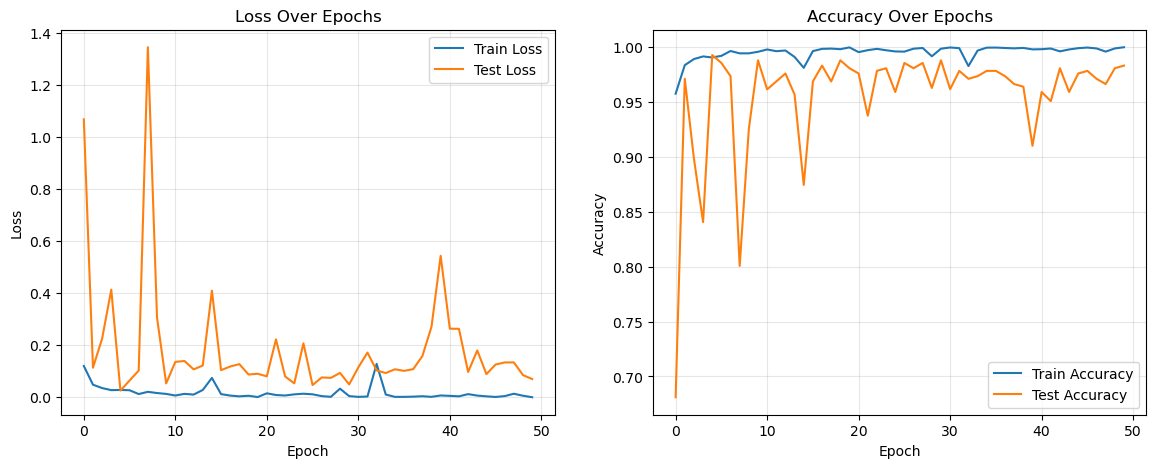

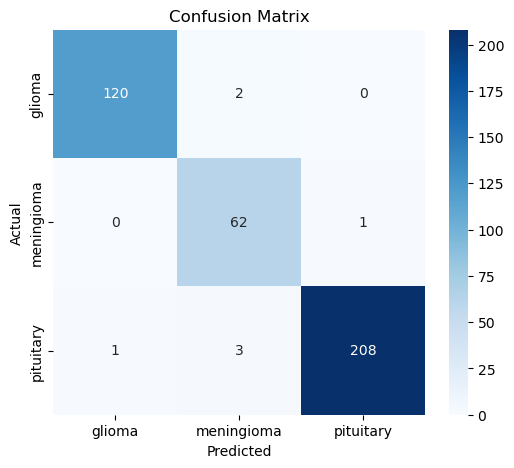

In [21]:
plot_results(results_MobileNetV3)
plot_confusion_matrix(results_MobileNetV3["labels"][-1], results_MobileNetV3["preds"][-1], class_names)

In [22]:
# save the model 
torch.save(model.state_dict(), "theBaseLineModels/MobileNetV3.pth")
torch.save(model, "theBaseLineModels/MobileNetV3_full.pth")

def convert_to_serializable(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


with open("theBaseLineModels/results_MobileNetV3.json", "w") as f:
    json.dump(results_MobileNetV3, f, indent=4, default=convert_to_serializable)


import pickle

with open("theBaseLineModels/results_MobileNetV3.pkl", "wb") as f:
    pickle.dump(results_MobileNetV3, f)

## EfficientNet-B0 BASELINE MODEL

In [23]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- TRANSFORMS (convert MRI 1-channel → 3-channel) ----
baseline_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # EfficientNet uses RGB input
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ---- DATA LOADERS ----
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=baseline_transforms,
    batch_size=32
)

# ---- LOAD EfficientNet-B0 ----
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# ---- REPLACE CLASSIFIER ----
# EfficientNet-B0 has classifier = Sequential(Dropout, Linear)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 3)

model = model.to(device)

# ---- LOSS & OPTIMIZER ----
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ---- SCHEDULER ----
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=5,
    factor=0.5,
    min_lr=1e-6
)

# ---- TRAIN ----
results_EfficientNetB0 = engine.train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=50,
    device=device
)

length of train_data 12735 length of test_data 397 class names ['glioma', 'meningioma', 'pituitary']


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.1359 | train_acc: 0.9505 | test_loss: 0.2367 | test_acc: 0.9255
Epoch: 2 | train_loss: 0.0484 | train_acc: 0.9842 | test_loss: 0.1750 | test_acc: 0.9399
Epoch: 3 | train_loss: 0.0269 | train_acc: 0.9905 | test_loss: 0.0651 | test_acc: 0.9784
Epoch: 4 | train_loss: 0.0287 | train_acc: 0.9910 | test_loss: 0.0714 | test_acc: 0.9784
Epoch: 5 | train_loss: 0.0186 | train_acc: 0.9934 | test_loss: 0.0926 | test_acc: 0.9663
Epoch: 6 | train_loss: 0.0241 | train_acc: 0.9918 | test_loss: 0.3375 | test_acc: 0.9149
Epoch: 7 | train_loss: 0.0177 | train_acc: 0.9947 | test_loss: 0.0949 | test_acc: 0.9760
Epoch: 8 | train_loss: 0.0067 | train_acc: 0.9977 | test_loss: 0.3558 | test_acc: 0.9294
Epoch: 9 | train_loss: 0.0066 | train_acc: 0.9974 | test_loss: 0.1078 | test_acc: 0.9832
Epoch: 10 | train_loss: 0.0362 | train_acc: 0.9885 | test_loss: 0.1320 | test_acc: 0.9784
Epoch: 11 | train_loss: 0.0130 | train_acc: 0.9961 | test_loss: 0.0471 | test_acc: 0.9856
Epoch: 12 | train_l

In [24]:
# evaluation
# use evaluate_model function in the evaluation model to check all the matrices
results_eval = evaluation.evaluate_model(
    model=model, 
    dataloader=test_dataloader,
    class_names=class_names,
    device=device
)

print("Accuracy:", results_eval["accuracy"])
print("\nClassification Report:\n", results_eval["classification_report"])
print("\nSpecificity:", results_eval["specificity"])
print("\nConfusion Matrix:\n", results_eval["confusion_matrix"])


Accuracy: 0.982367758186398

Classification Report:
               precision    recall  f1-score   support

      glioma       0.96      0.98      0.97       122
  meningioma       0.98      0.98      0.98        63
   pituitary       1.00      0.98      0.99       212

    accuracy                           0.98       397
   macro avg       0.98      0.98      0.98       397
weighted avg       0.98      0.98      0.98       397


Specificity: {'glioma': 0.9818181818181818, 'meningioma': 0.9970059880239521, 'pituitary': 0.9945945945945946}

Confusion Matrix:
 [[120   1   1]
 [  1  62   0]
 [  4   0 208]]


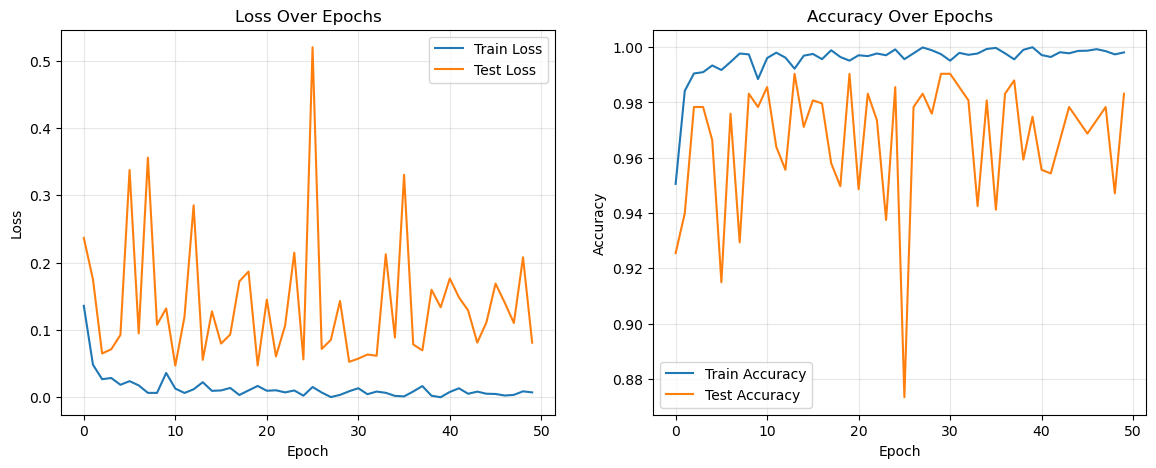

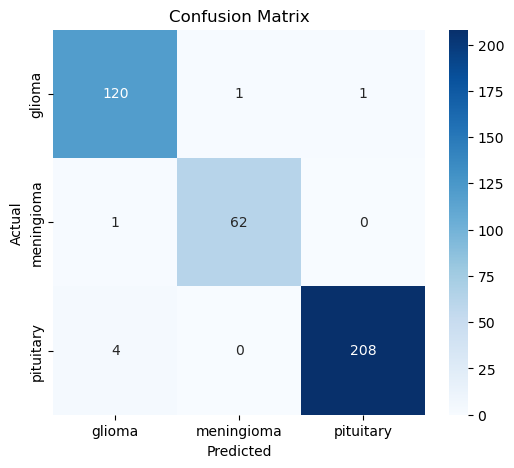

In [25]:
plot_results(results_EfficientNetB0)
plot_confusion_matrix(results_EfficientNetB0["labels"][-1], results_EfficientNetB0["preds"][-1], class_names)

In [26]:
# save the model 
torch.save(model.state_dict(), "theBaseLineModels/EfficientNetB0.pth")
torch.save(model, "theBaseLineModels/EfficientNetB0_full.pth")

def convert_to_serializable(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


with open("theBaseLineModels/results_EfficientNetB0.json", "w") as f:
    json.dump(results_EfficientNetB0, f, indent=4, default=convert_to_serializable)


import pickle

with open("theBaseLineModels/results_EfficientNetB0.pkl", "wb") as f:
    pickle.dump(results_EfficientNetB0, f)

## RegNet-Y-400MF BASELINE MODEL

In [27]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- TRANSFORMS (convert MRI 1-channel → 3-channel) ----
baseline_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # RegNet expects RGB
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ---- DATA LOADERS ----
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=baseline_transforms,
    batch_size=32
)

# ---- LOAD RegNet-Y-400MF ----
model = models.regnet_y_400mf(weights=models.RegNet_Y_400MF_Weights.DEFAULT)

# ---- REPLACE CLASSIFIER ----
# RegNet's classifier is in model.fc
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 3)

model = model.to(device)

# ---- LOSS & OPTIMIZER ----
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ---- SCHEDULER ----
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=5,
    factor=0.5,
    min_lr=1e-6
)

# ---- TRAIN ----
results_RegNetY400 = engine.train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=50,
    device=device
)

length of train_data 12735 length of test_data 397 class names ['glioma', 'meningioma', 'pituitary']


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.1324 | train_acc: 0.9512 | test_loss: 0.1404 | test_acc: 0.9567
Epoch: 2 | train_loss: 0.0441 | train_acc: 0.9852 | test_loss: 0.7689 | test_acc: 0.8029
Epoch: 3 | train_loss: 0.0365 | train_acc: 0.9878 | test_loss: 0.1658 | test_acc: 0.9436
Epoch: 4 | train_loss: 0.0245 | train_acc: 0.9926 | test_loss: 0.1487 | test_acc: 0.9543
Epoch: 5 | train_loss: 0.0273 | train_acc: 0.9903 | test_loss: 0.1310 | test_acc: 0.9591
Epoch: 6 | train_loss: 0.0164 | train_acc: 0.9939 | test_loss: 0.1428 | test_acc: 0.9567
Epoch: 7 | train_loss: 0.0210 | train_acc: 0.9937 | test_loss: 0.0517 | test_acc: 0.9832
Epoch: 8 | train_loss: 0.0028 | train_acc: 0.9994 | test_loss: 0.0157 | test_acc: 0.9928
Epoch: 9 | train_loss: 0.0233 | train_acc: 0.9921 | test_loss: 0.1116 | test_acc: 0.9543
Epoch: 10 | train_loss: 0.0226 | train_acc: 0.9926 | test_loss: 0.0846 | test_acc: 0.9808
Epoch: 11 | train_loss: 0.0108 | train_acc: 0.9967 | test_loss: 0.2974 | test_acc: 0.9016
Epoch: 12 | train_l

In [28]:
# evaluation
# use evaluate_model function in the evaluation model to check all the matrices
results_eval = evaluation.evaluate_model(
    model=model, 
    dataloader=test_dataloader,
    class_names=class_names,
    device=device
)

print("Accuracy:", results_eval["accuracy"])
print("\nClassification Report:\n", results_eval["classification_report"])
print("\nSpecificity:", results_eval["specificity"])
print("\nConfusion Matrix:\n", results_eval["confusion_matrix"])


Accuracy: 0.9848866498740554

Classification Report:
               precision    recall  f1-score   support

      glioma       1.00      0.98      0.99       122
  meningioma       0.95      1.00      0.98        63
   pituitary       0.99      0.99      0.99       212

    accuracy                           0.98       397
   macro avg       0.98      0.99      0.98       397
weighted avg       0.99      0.98      0.98       397


Specificity: {'glioma': 1.0, 'meningioma': 0.9910179640718563, 'pituitary': 0.9837837837837838}

Confusion Matrix:
 [[119   0   3]
 [  0  63   0]
 [  0   3 209]]


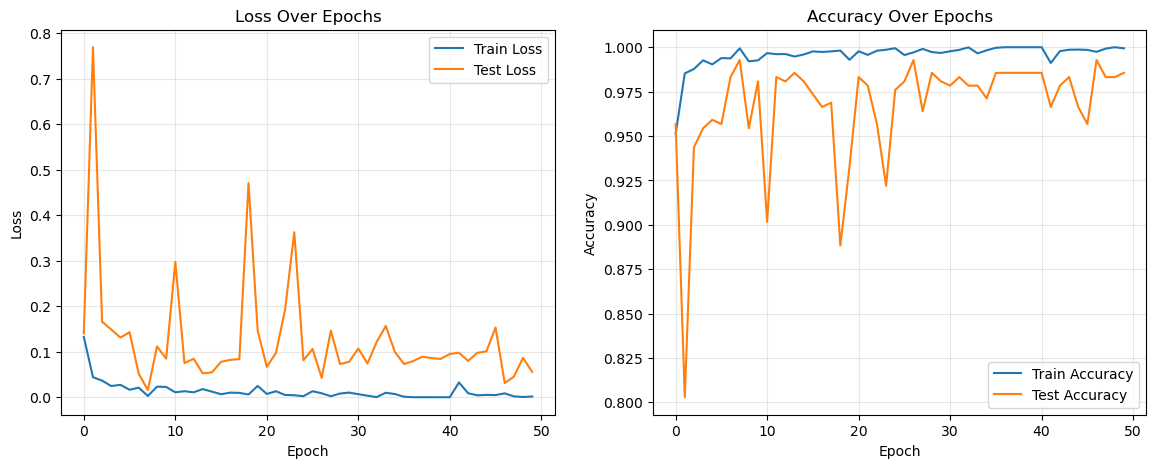

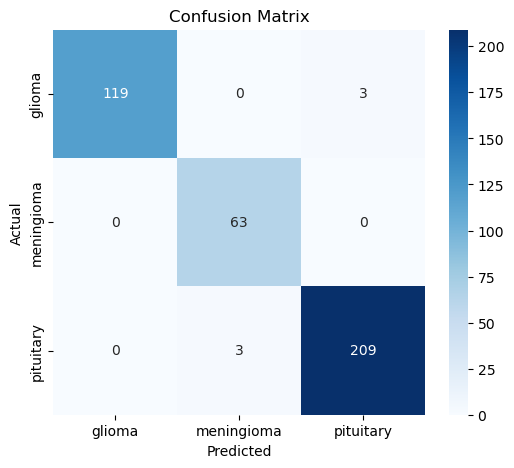

In [29]:
plot_results(results_RegNetY400)
plot_confusion_matrix(results_RegNetY400["labels"][-1], results_RegNetY400["preds"][-1], class_names)

In [30]:
# save the model 
torch.save(model.state_dict(), "theBaseLineModels/RegNetY400.pth")
torch.save(model, "theBaseLineModels/RegNetY400_full.pth")

def convert_to_serializable(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


with open("theBaseLineModels/results_RegNetY400.json", "w") as f:
    json.dump(results_RegNetY400, f, indent=4, default=convert_to_serializable)


import pickle

with open("theBaseLineModels/results_RegNetY400.pkl", "wb") as f:
    pickle.dump(results_RegNetY400, f)

## AlexNet BASELINE MODEL

In [31]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- TRANSFORMS (convert MRI 1-channel → 3-channel) ----
baseline_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # AlexNet needs RGB
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ---- DATA LOADERS ----
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=baseline_transforms,
    batch_size=32
)

# ---- LOAD AlexNet ----
model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)

# ---- MODIFY CLASSIFIER (last Linear layer) ----
in_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(in_features, 3)

model = model.to(device)

# ---- LOSS & OPTIMIZER ----
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ---- LEARNING RATE SCHEDULER ----
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=5,
    factor=0.5,
    min_lr=1e-6
)

# ---- TRAIN ----
results_AlexNet = engine.train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=50,
    device=device
)


length of train_data 12735 length of test_data 397 class names ['glioma', 'meningioma', 'pituitary']


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0613 | train_acc: 0.4846 | test_loss: 1.2985 | test_acc: 0.1514
Epoch: 2 | train_loss: 1.0482 | train_acc: 0.4880 | test_loss: 1.2185 | test_acc: 0.1514
Epoch: 3 | train_loss: 1.0476 | train_acc: 0.4880 | test_loss: 1.2655 | test_acc: 0.1514
Epoch: 4 | train_loss: 1.0476 | train_acc: 0.4880 | test_loss: 1.2699 | test_acc: 0.1514
Epoch: 5 | train_loss: 1.0471 | train_acc: 0.4880 | test_loss: 1.2479 | test_acc: 0.1514
Epoch: 6 | train_loss: 1.0472 | train_acc: 0.4880 | test_loss: 1.2431 | test_acc: 0.1514
Epoch: 7 | train_loss: 1.0461 | train_acc: 0.4880 | test_loss: 1.2496 | test_acc: 0.1514
Epoch: 8 | train_loss: 1.0473 | train_acc: 0.4880 | test_loss: 1.3411 | test_acc: 0.1514
Epoch: 9 | train_loss: 1.0473 | train_acc: 0.4880 | test_loss: 1.2394 | test_acc: 0.1514
Epoch: 10 | train_loss: 1.0467 | train_acc: 0.4880 | test_loss: 1.2487 | test_acc: 0.1514
Epoch: 11 | train_loss: 1.0459 | train_acc: 0.4880 | test_loss: 1.2214 | test_acc: 0.1514
Epoch: 12 | train_l

In [32]:
# evaluation
# use evaluate_model function in the evaluation model to check all the matrices
results_eval = evaluation.evaluate_model(
    model=model, 
    dataloader=test_dataloader,
    class_names=class_names,
    device=device
)

print("Accuracy:", results_eval["accuracy"])
print("\nClassification Report:\n", results_eval["classification_report"])
print("\nSpecificity:", results_eval["specificity"])
print("\nConfusion Matrix:\n", results_eval["confusion_matrix"])


Accuracy: 0.15869017632241814

Classification Report:
               precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       122
  meningioma       0.16      1.00      0.27        63
   pituitary       0.00      0.00      0.00       212

    accuracy                           0.16       397
   macro avg       0.05      0.33      0.09       397
weighted avg       0.03      0.16      0.04       397


Specificity: {'glioma': 1.0, 'meningioma': 0.0, 'pituitary': 1.0}

Confusion Matrix:
 [[  0 122   0]
 [  0  63   0]
 [  0 212   0]]


C:\Users\Alzubair\anaconda3\envs\dl\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Alzubair\anaconda3\envs\dl\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Alzubair\anaconda3\envs\dl\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

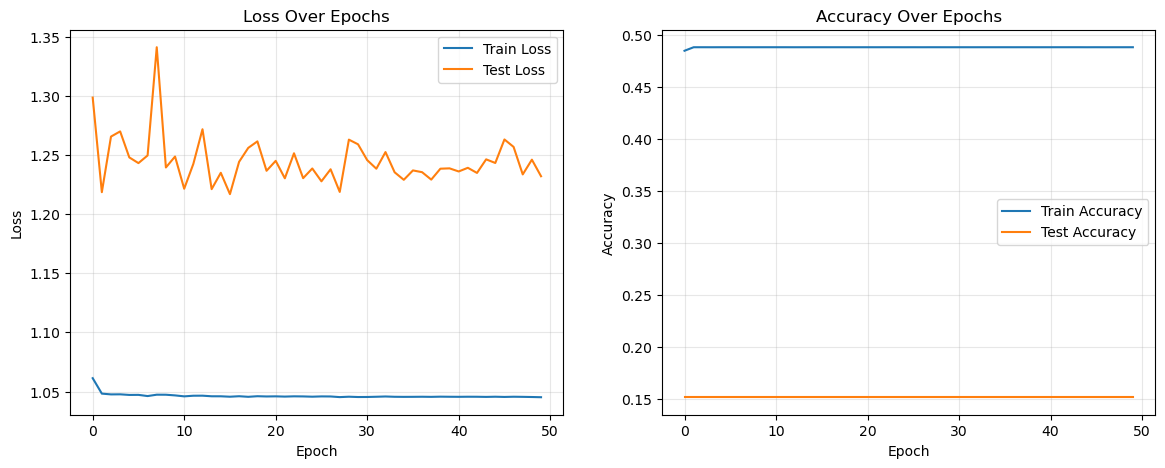

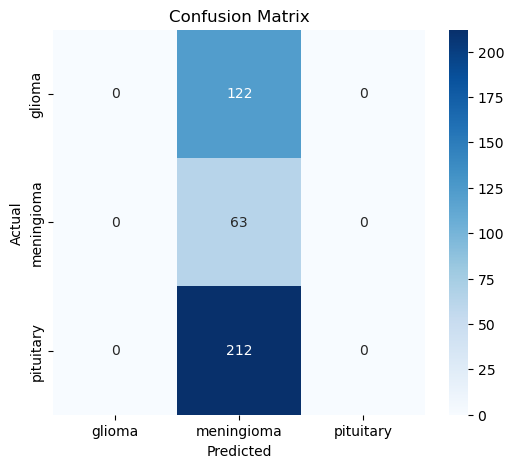

In [33]:
plot_results(results_AlexNet)
plot_confusion_matrix(results_AlexNet["labels"][-1], results_AlexNet["preds"][-1], class_names)

In [34]:
# save the model 
torch.save(model.state_dict(), "theBaseLineModels/AlexNet.pth")
torch.save(model, "theBaseLineModels/AlexNet_full.pth")

def convert_to_serializable(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


with open("theBaseLineModels/results_AlexNet.json", "w") as f:
    json.dump(results_AlexNet, f, indent=4, default=convert_to_serializable)


import pickle

with open("theBaseLineModels/results_AlexNet.pkl", "wb") as f:
    pickle.dump(results_AlexNet, f)